In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np




In [7]:
#abrir grd parquet para explorar los datos y hacer un análisis de los mismos.
#grd_parquet = pd.read_parquet('./grd_procesado.parquet')
grd_parquet = pd.read_parquet('/Users/maria/Documents/Business Intehlligence/W1/grd_procesado.parquet')
grd_parquet.head()  # Mostrar las primeras filas del DataFrame para explorar los datos


grd_parquet

,COD_ESTABLECIMIENTO,CIP_ENCRIPTADO,SEXO,FECHA_NACIMIENTO,PROVINCIA,COMUNA_REGISTRADA,PREVISION,SERVICIO_SALUD,TIPO_PROCEDENCIA,TIPO_INGRESO,...,CAMAS_CRITICAS,POB_MULT_ESTAB,COMUNA_CON_ESTAB_AC,FALLECIDO,CRITICAS_PROP,CAMAS_COMUNA,CRITICAS_COMUNA,CAMAS_1000HAB,CRITICAS_1000HAB,TASA_MORTALIDAD_COMUNA
0,118100,467373,HOMBRE,1969-09-10,CONCEPCION,SAN PEDRO DE LA PAZ,FONASA INSTITUCIONAL - (MAI) B,CONCEPCIÓN,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,...,113,0.090303,0,0,0.128118,882,113,3.717488,0.476277,0.117963
1,118100,562854,HOMBRE,1956-02-07,CONCEPCION,CORONEL,FONASA INSTITUCIONAL - (MAI) A,CONCEPCIÓN,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,...,113,0.090303,1,0,0.128118,882,113,3.717488,0.476277,0.117963
2,118100,199980,MUJER,1960-02-28,CONCEPCION,SAN PEDRO DE LA PAZ,FONASA INSTITUCIONAL - (MAI) A,CONCEPCIÓN,APS CONSULTORIO (CESFAM),URGENCIA,...,113,0.090303,0,0,0.128118,882,113,3.717488,0.476277,0.117963
3,118100,857926,MUJER,1933-01-12,CONCEPCION,CHIGUAYANTE,FONASA INSTITUCIONAL - (MAI) D,CONCEPCIÓN,"OTRAS INSTITUCIONES SALUD (CLÍNICAS PRIVADAS, ...",URGENCIA,...,113,0.090303,0,1,0.128118,882,113,3.717488,0.476277,0.117963
4,118100,284629,HOMBRE,1951-05-03,CURICO,TENO,FONASA INSTITUCIONAL - (MAI) C,DEL MAULE,"CENTRO ESPECIALIDADES (CDT, CRS, CONSULTORIO A...",PROGRAMADA,...,113,0.090303,0,0,0.128118,882,113,3.717488,0.476277,0.117963
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367890,111101,73167108,HOMBRE,1985-03-20,SANTIAGO,CERRILLOS,FONASA INSTITUCIONAL - (MAI) B,METROPOLITANO CENTRAL,"OTRAS INSTITUCIONES (CÁRCEL, HOGARES DE ANCIAN...",URGENCIA,...,88,0.169789,0,0,0.195122,451,88,0.76856,0.149963,0.227393
367891,118100,100641520,HOMBRE,2024-06-14,CONCEPCION,FLORIDA,FONASA INSTITUCIONAL - (MAI) B,CONCEPCIÓN,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,...,128,0.090303,0,0,0.157248,814,128,3.394835,0.533832,0.117963
367892,116105,76585409,MUJER,1959-02-01,TALCA,TALCA,FONASA INSTITUCIONAL - (MAI) A,DEL MAULE,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,...,155,0.123584,1,0,0.236641,655,155,2.70277,0.639587,0.157606
367893,120101,67448378,MUJER,1992-06-27,BIO-BIO,MULCHEN,FONASA INSTITUCIONAL - (MAI) B,BIOBIO,OTROS HOSPITALES DE LA RED,OBSTETRICA,...,113,0.153472,0,0,0.210037,538,113,2.404459,0.505026,0.140465


In [44]:
#valores nulos en el parquet
grd_parquet.isnull().sum()  # Contar los valores nulos en cada columna del DataFrame parquet


COD_ESTABLECIMIENTO          0
CIP_ENCRIPTADO               0
SEXO                         0
FECHA_NACIMIENTO             0
PROVINCIA                    0
COMUNA_REGISTRADA            0
PREVISION                    0
SERVICIO_SALUD               0
TIPO_PROCEDENCIA             0
TIPO_INGRESO                 0
FECHA_INGRESO                0
FECHAALTA                    0
TIPOALTA                     0
DIAGNOSTICO1                 0
DIAGNOSTICO2                 9
DIAGNOSTICO3              4920
PROCEDIMIENTO1             127
PROCEDIMIENTO2            2329
IR_29301_COD_GRD             0
IR_29301_PESO                0
IR_29301_SEVERIDAD           0
IR_29301_MORTALIDAD          0
YEAR                         0
EDAD                         0
DIAS_ESTANCIA                0
N_COMORBILIDADES             0
N_PROCEDIMIENTOS             0
INDICE_CHARLSON              0
DESCRIPCION                  0
SECCION                      0
COD_REGION                   0
REGION                       0
ESTABLEC

In [45]:
grd_femenino = grd_parquet[grd_parquet['SEXO'] == 'MUJER']
grd_femenino.head()  # Mostrar las primeras filas del DataFrame filtrado por sexo femenino

,COD_ESTABLECIMIENTO,CIP_ENCRIPTADO,SEXO,FECHA_NACIMIENTO,PROVINCIA,COMUNA_REGISTRADA,PREVISION,SERVICIO_SALUD,TIPO_PROCEDENCIA,TIPO_INGRESO,...,CAMAS_CRITICAS,POB_MULT_ESTAB,COMUNA_CON_ESTAB_AC,FALLECIDO,CRITICAS_PROP,CAMAS_COMUNA,CRITICAS_COMUNA,CAMAS_1000HAB,CRITICAS_1000HAB,TASA_MORTALIDAD_COMUNA
2,118100,199980,MUJER,1960-02-28,CONCEPCION,SAN PEDRO DE LA PAZ,FONASA INSTITUCIONAL - (MAI) A,CONCEPCIÓN,APS CONSULTORIO (CESFAM),URGENCIA,...,113,0.090303,0,0,0.128118,882,113,3.717488,0.476277,0.117963
3,118100,857926,MUJER,1933-01-12,CONCEPCION,CHIGUAYANTE,FONASA INSTITUCIONAL - (MAI) D,CONCEPCIÓN,"OTRAS INSTITUCIONES SALUD (CLÍNICAS PRIVADAS, ...",URGENCIA,...,113,0.090303,0,1,0.128118,882,113,3.717488,0.476277,0.117963
9,116110,900702,MUJER,1947-05-10,LINARES,PARRAL,FONASA INSTITUCIONAL - (MAI) B,DEL MAULE,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,...,0,0.135324,1,0,0.0,102,0,2.309155,0.0,0.211155
11,118100,1260221,MUJER,1959-10-19,CONCEPCION,CORONEL,FONASA INSTITUCIONAL - (MAI) A,CONCEPCIÓN,OTROS HOSPITALES DE LA RED,URGENCIA,...,113,0.090303,1,0,0.128118,882,113,3.717488,0.476277,0.117963
13,118100,1192972,MUJER,1993-12-29,CONCEPCION,CONCEPCION,FONASA INSTITUCIONAL - (MAI) A,CONCEPCIÓN,SERVICIO EMERGENCIA (DOMICILIO),URGENCIA,...,113,0.090303,1,0,0.128118,882,113,3.717488,0.476277,0.117963


In [46]:
grd_femenino.shape

(154431, 52)

In [47]:
grd_femenino.columns  # Mostrar todas las columnas del DataFrame filtrado por sexo femenino

Index(['COD_ESTABLECIMIENTO', 'CIP_ENCRIPTADO', 'SEXO', 'FECHA_NACIMIENTO',
       'PROVINCIA', 'COMUNA_REGISTRADA', 'PREVISION', 'SERVICIO_SALUD',
       'TIPO_PROCEDENCIA', 'TIPO_INGRESO', 'FECHA_INGRESO', 'FECHAALTA',
       'TIPOALTA', 'DIAGNOSTICO1', 'DIAGNOSTICO2', 'DIAGNOSTICO3',
       'PROCEDIMIENTO1', 'PROCEDIMIENTO2', 'IR_29301_COD_GRD', 'IR_29301_PESO',
       'IR_29301_SEVERIDAD', 'IR_29301_MORTALIDAD', 'YEAR', 'EDAD',
       'DIAS_ESTANCIA', 'N_COMORBILIDADES', 'N_PROCEDIMIENTOS',
       'INDICE_CHARLSON', 'DESCRIPCION', 'SECCION', 'COD_REGION', 'REGION',
       'ESTABLECIMIENTO', 'COD_COMUNA', 'COMUNA_ESTAB', 'LATITUD', 'LONGITUD',
       'PRESTADOR', 'COMPLEJIDAD_ESTAB', 'POB_COMUNA', 'POB_REGION',
       'CAMAS_TOTALES', 'CAMAS_CRITICAS', 'POB_MULT_ESTAB',
       'COMUNA_CON_ESTAB_AC', 'FALLECIDO', 'CRITICAS_PROP', 'CAMAS_COMUNA',
       'CRITICAS_COMUNA', 'CAMAS_1000HAB', 'CRITICAS_1000HAB',
       'TASA_MORTALIDAD_COMUNA'],
      dtype='str')

In [48]:
#top 5 diagnosticos más frecuentes en mujeres
top_diagnosticos_femeninos = (
    grd_femenino['DESCRIPCION']
    .value_counts()
    .head(5)
)
top_diagnosticos_femeninos 


DESCRIPCION
COVID-19, virus identificado                             12210
Síndrome de dificultad respiratoria del recién nacido     2982
Fractura del cuello de fémur, cerrada                     2834
Leucemia linfoblástica aguda (Todas)                      2232
Enfermedad aterosclerótica del corazón                    1920
Name: count, dtype: int64[pyarrow]

In [49]:
#top 5 diagnosticos mas frecuentes en mujeres por año
top_diagnosticos_femeninos_anio = (
    grd_femenino.groupby('YEAR')['DESCRIPCION'].value_counts().groupby('YEAR').head(5)
)
top_diagnosticos_femeninos_anio

YEAR  DESCRIPCION                                          
2019  Síndrome de dificultad respiratoria del recién nacido     453
      Sepsis no especificada                                    355
      Leucemia linfoblástica aguda (Todas)                      295
      Fractura del cuello de fémur, cerrada                     294
      Enfermedad aterosclerótica del corazón                    272
2020  COVID-19, virus identificado                             3465
      Síndrome de dificultad respiratoria del recién nacido     469
      Fractura del cuello de fémur, cerrada                     341
      Leucemia linfoblástica aguda (Todas)                      335
      Sepsis no especificada                                    291
2021  COVID-19, virus identificado                             7587
      Síndrome de dificultad respiratoria del recién nacido     529
      Fractura del cuello de fémur, cerrada                     423
      Leucemia linfoblástica aguda (Todas)              

In [50]:
#top 5 diagnosticos en mujeres por rango etario
#definir rangos etarios
bins = [0, 18, 30, 45, 60, 75, 90, 120]
labels = ['0-18', '19-30', '31-45', '46-60', '61-75', '76-90', '91-120']
grd_femenino['EDAD'] = pd.cut(grd_femenino['EDAD'], bins=bins, labels=labels, right=False)

top_diagnosticos_femeninos_rango = (
    grd_femenino.groupby('EDAD')['DESCRIPCION'].value_counts().groupby('EDAD').head(5)
)
top_diagnosticos_femeninos_rango

EDAD    DESCRIPCION                                                           
0-18    Síndrome de dificultad respiratoria del recién nacido                     2982
        Leucemia linfoblástica aguda (Todas)                                      1283
        Otros recién nacidos pretérmino                                           1028
        Neumonía debida a virus sincitial respiratorio                             818
        Otro peso bajo al nacer                                                    673
19-30   COVID-19, virus identificado                                               517
        Leucemia linfoblástica aguda (Todas)                                       332
        Leucemia mieloblástica aguda (LMA)                                         159
        Embarazo tubárico                                                          108
        Benzodiazepinas                                                             78
31-45   COVID-19, virus identificado               

In [51]:

#mujeres vs hombres porcentaje
grd_parquet['SEXO'].value_counts(normalize=True) * 100  # Calcular el porcentaje de mujeres y hombres en el DataFrame parquet   

SEXO
HOMBRE         58.011661
MUJER          41.976923
DESCONOCIDO     0.011416
Name: proportion, dtype: float64

In [52]:
grd_masculino = grd_parquet[grd_parquet['SEXO'] == 'HOMBRE']
top_5_diagnosticos_masculinos = (
    grd_masculino['DESCRIPCION']
    .value_counts()
    .head(5)
)
top_5_diagnosticos_masculinos

DESCRIPCION
COVID-19, virus identificado                                              18658
Enfermedad aterosclerótica del corazón                                     6541
Diabetes mellitus tipo 2 con complicaciones  circulatorias periféricas     3985
Síndrome de dificultad respiratoria del recién nacido                      3541
Leucemia linfoblástica aguda (Todas)                                       2774
Name: count, dtype: int64[pyarrow]

In [53]:
#top 5 diagnisticos mas frecuentes en hombres por año
top_diagnosticos_masculinos_anio = (
    grd_masculino.groupby('YEAR')['DESCRIPCION'].value_counts().groupby('YEAR').head(5)
)
top_diagnosticos_masculinos_anio

YEAR  DESCRIPCION                                                           
2019  Enfermedad aterosclerótica del corazón                                      806
      Síndrome de dificultad respiratoria del recién nacido                       548
      Diabetes mellitus tipo 2 con complicaciones  circulatorias periféricas      457
      Sepsis no especificada                                                      426
      Leucemia linfoblástica aguda (Todas)                                        392
2020  COVID-19, virus identificado                                               6099
      Enfermedad aterosclerótica del corazón                                      678
      Síndrome de dificultad respiratoria del recién nacido                       540
      Diabetes mellitus tipo 2 con complicaciones  circulatorias periféricas      489
      Leucemia linfoblástica aguda (Todas)                                        426
2021  COVID-19, virus identificado                             

In [54]:
#rangos etarios para hombres
grd_masculino = grd_masculino.copy()

grd_masculino['EDAD'] = pd.cut(
    grd_masculino['EDAD'],
    bins=bins,
    labels=labels,
    right=False
)

top_5_diagnosticos_masculinos_rango = (
    grd_masculino.groupby('EDAD', observed=True)['DESCRIPCION']
    .value_counts()
    .groupby(level='EDAD')
    .head(5)
)
top_5_diagnosticos_masculinos_rango

EDAD    DESCRIPCION                                                                              
0-18    Síndrome de dificultad respiratoria del recién nacido                                        3540
        Leucemia linfoblástica aguda (Todas)                                                         1657
        Otros recién nacidos pretérmino                                                              1216
        Neumonía debida a virus sincitial respiratorio                                               1086
        Otro peso bajo al nacer                                                                       703
19-30   COVID-19, virus identificado                                                                  558
        Leucemia linfoblástica aguda (Todas)                                                          459
        Traumatismo del intestino delgado, con herida dentro de la cavidad abdominal                  231
        Traumatismo del hígado y de la vesícula biliar

In [9]:
#dias de estancia por sexo con medidas de tendencia central y dispersión
dias_estancia_sexo = grd_parquet.groupby('SEXO')['DIAS_ESTANCIA'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])
dias_estancia_sexo



/var/folders/4r/bv24jr955x9g3b9fjjv0bm_c0000gn/T/ipykernel_38043/1114479893.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dias_estancia_sexo = grd_parquet.groupby('SEXO')['DIAS_ESTANCIA'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])


,mean,median,std,min,max,count
SEXO,,,,,,
DESCONOCIDO,23.571429,15.0,29.003905,0,156,42
HOMBRE,23.453829,15.0,29.978199,0,831,213422
MUJER,22.756020,15.0,29.694106,0,1266,154431


In [23]:
#cuales son los diagnosticos con mas dias de estancia asociados absolutos, tanto para hombres como para mujeres
#o sea si hay un diagnostico con 1266 dias de estancia (dia de estancia max en mujeres) y otro con 1265 dias de estancia (dia de estancia max en hombres) se debe mostrar ambos diagnosticos, aunque el diagnostico de mujeres tenga un dia mas de estancia que el de hombres.

dias_estancia_diagnosticos = (
    grd_parquet.groupby(['SEXO', 'DESCRIPCION'])['DIAS_ESTANCIA']
    .agg([ 'max'])
    .reset_index()
    .sort_values(by='max', ascending=False)
    .head(10)
)
dias_estancia_diagnosticos

/var/folders/4r/bv24jr955x9g3b9fjjv0bm_c0000gn/T/ipykernel_38043/417784960.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grd_parquet.groupby(['SEXO', 'DESCRIPCION'])['DIAS_ESTANCIA']


,SEXO,DESCRIPCION,max
12917,MUJER,"Insuficiencia respiratoria aguda, Tipo no espe...",1266.0
11788,MUJER,Enfermedades de las neuronas motoras,992.0
14350,MUJER,Parálisis cerebral espástica cuadripléjica,949.0
12920,MUJER,"Insuficiencia respiratoria crónica, Tipo II (h...",842.0
8702,HOMBRE,Otras polineuropatías inflamatorias,831.0
8587,HOMBRE,Otras malformaciones congénitas de la tráquea,806.0
11680,MUJER,"Enfermedad de la médula espinal, no especificada",804.0
13961,MUJER,Otras obstrucciones intestinales y las no espe...,799.0
11424,MUJER,"Desnutrición proteicocalórica severa, no espec...",789.0
14018,MUJER,Otras septicemias especificadas,776.0


In [55]:
# Propuesta 2

In [56]:
grd_alta = grd_parquet[grd_parquet['COMPLEJIDAD_ESTAB'] == 'Alta Complejidad']
print(f"Registros en hospitales de Alta Complejidad: {len(grd_alta):,} de {len(grd_parquet):,} totales")
grd_alta[['IR_29301_COD_GRD', 'DIAS_ESTANCIA', 'IR_29301_PESO']].head()

Registros en hospitales de Alta Complejidad: 358,743 de 367,895 totales


,IR_29301_COD_GRD,DIAS_ESTANCIA,IR_29301_PESO
0,011012,29,3.6066
1,091202,22,2.0678
2,041023,21,5.8207
3,061203,19,3.5647
4,051042,17,3.7833


In [57]:
# Percentiles de DIAS_ESTANCIA y IR_29301_PESO en hospitales de Alta Complejidad
grd_stats = ( grd_alta.groupby('IR_29301_COD_GRD', observed=True)['DIAS_ESTANCIA'].agg(n='count', mediana='median',q1=lambda x: x.quantile(0.25),q3=lambda x: x.quantile(0.75)).reset_index())
grd_stats['ric'] = grd_stats['q3'] - grd_stats['q1']
grd_stats['limite_superior'] = grd_stats['q3'] + 1.5 * grd_stats['ric']
grd_stats_validos = grd_stats[grd_stats['n'] >= 30]
grd_stats_validos.sort_values('limite_superior', ascending=False).head()


,IR_29301_COD_GRD,n,mediana,q1,q3,ric,limite_superior
95,158023,282,103.5,32.0,148.50,116.50,323.250
99,158043,232,84.5,54.0,124.25,70.25,229.625
97,158033,2119,77.0,28.0,104.00,76.00,218.000
26,051013,139,59.0,30.0,99.50,69.50,203.750
103,158063,307,49.0,30.0,98.00,68.00,200.000


In [58]:
grd_alta = grd_alta.merge(grd_stats_validos[['IR_29301_COD_GRD', 'mediana', 'limite_superior']],on='IR_29301_COD_GRD', how='left')
grd_alta['clasificable'] = grd_alta['limite_superior'].notna()
grd_alta['outlier_superior'] = grd_alta['clasificable'] & (grd_alta['DIAS_ESTANCIA'] > grd_alta['limite_superior'])
grd_alta['dias_exceso'] = np.where(grd_alta['outlier_superior'], grd_alta['DIAS_ESTANCIA'] - grd_alta['mediana'], 0)

grd_alta[['IR_29301_COD_GRD', 'DIAS_ESTANCIA', 'mediana', 'limite_superior', 'outlier_superior', 'dias_exceso']].head(10)

,IR_29301_COD_GRD,DIAS_ESTANCIA,mediana,limite_superior,outlier_superior,dias_exceso
0,011012,29,9.0,35.0,False,0.0
1,091202,22,16.0,42.5,False,0.0
2,041023,21,20.0,60.5,False,0.0
3,061203,19,12.0,51.0,False,0.0
4,051042,17,11.0,28.0,False,0.0
5,011102,7,8.0,34.0,False,0.0
6,041203,4,5.0,31.0,False,0.0
7,011102,9,8.0,34.0,False,0.0
8,051043,21,15.0,51.5,False,0.0
9,091203,19,27.0,71.5,False,0.0


In [59]:
n_total = len(grd_alta)
n_clasif = grd_alta['clasificable'].sum()
n_out = grd_alta['outlier_superior'].sum()
dias_exceso_total = grd_alta['dias_exceso'].sum()
n_anios = grd_alta['YEAR'].nunique()
camas_equivalentes = dias_exceso_total / n_anios / 365

print(f"Total registros Alta Complejidad: {n_total:,}")
print(f"Registros clasificables (GRD con n>=30): {n_clasif:,} ({n_clasif/n_total*100:.1f}%)")
print(f"Outliers superiores: {n_out:,} ({n_out/n_total*100:.2f}% del total)")
print(f"Total días-cama en exceso ({grd_alta['YEAR'].min()}-{grd_alta['YEAR'].max()}): {dias_exceso_total:,.0f}")
print(f"Exceso promedio por caso outlier: {grd_alta.loc[grd_alta['outlier_superior'], 'dias_exceso'].mean():.1f} días")
print(f"Equivalente en camas ocupadas todo el año (promedio anual/365): {camas_equivalentes:.0f} camas")

Total registros Alta Complejidad: 358,743
Registros clasificables (GRD con n>=30): 358,699 (100.0%)
Outliers superiores: 21,193 (5.91% del total)
Total días-cama en exceso (2019-2024): 1,539,616
Exceso promedio por caso outlier: 72.6 días
Equivalente en camas ocupadas todo el año (promedio anual/365): 703 camas


In [60]:
# Codigos grd con mayor exceso de días-cama
outliers = grd_alta[grd_alta['outlier_superior']]

top_grd = (outliers.groupby('IR_29301_COD_GRD', observed=True).agg(n_outliers=('dias_exceso', 'size'),dias_exceso=('dias_exceso', 'sum'),diagnostico_frecuente=('DESCRIPCION', lambda x: x.value_counts().index[0])).sort_values('dias_exceso', ascending=False))
top_grd['pct_del_total'] = top_grd['dias_exceso'] / dias_exceso_total * 100
top_grd.head(10)

,n_outliers,dias_exceso,diagnostico_frecuente,pct_del_total
IR_29301_COD_GRD,,,,
041023,4344,353682.0,"COVID-19, virus identificado",22.972092
041013,1112,180763.0,"COVID-19, virus identificado",11.740785
041203,2594,125293.0,"COVID-19, virus identificado",8.137938
061203,1373,103052.0,Perforación del intestino (no traumática),6.693357
051203,605,49900.0,Diabetes mellitus tipo 2 con complicaciones c...,3.241068
081023,386,35010.0,Diabetes mellitus tipo 2 con complicaciones c...,2.273944
081203,453,33649.0,"Fractura del cuello de fémur, cerrada",2.185545
091403,319,27186.0,Leucemia linfoblástica aguda (Todas),1.765765
051403,748,24634.0,Infarto subendocárdico agudo del miocardio,1.600009


In [61]:
# Secciones de CIE-10 con mayor exceso de días-cama
top_seccion = (
    outliers.groupby('SECCION', observed=True)
    .agg(n_outliers=('dias_exceso', 'size'), dias_exceso=('dias_exceso', 'sum'))
    .sort_values('dias_exceso', ascending=False)
)
top_seccion['pct_del_total'] = top_seccion['dias_exceso'] / dias_exceso_total * 100
top_seccion.head(10)

,n_outliers,dias_exceso,pct_del_total
SECCION,,,
"T80-T88 COMPLICACIONES DE LA ATENCIÓN QUIRÚRGICA Y MÉDICA, NO CLASIFICADAS BAJO OTRO CONCEPTO",1503,111934.0,7.270254
"C81-C96 NEOPLASIA MALIGNA DE TEJIDOS LINFOIDE, HEMOPOÝETICO Y RELACIONADOS",995,58223.0,3.781657
I60-I69 ENFERMEDADES CEREBROVASCULARES,767,56682.0,3.681567
U00-U49 ASIGNACION PROVISIONAL DE NUEVAS ENFERMEDADES DE ETIOLOGIA INCIERTA,805,55497.0,3.604600
K55-K64 OTRAS ENFERMEDADES DE LOS INTESTINOS,672,55389.5,3.597618
I30-I52 OTRAS FORMAS DE ENFERMEDAD CARDIACA,1206,54979.5,3.570988
C15-C26 NEOPLASIAS MALIGNAS DE ÓRGANOS DIGESTIVOS,811,49741.5,3.230773
P19-P29 TRASTORNOS RESPIRATORIOS Y CARDIOVASCULARES ESPECÍFICOS DEL PERÍODO PERINATAL,503,46128.5,2.996104
A30-A49 OTRAS ENFERMEDADES BACTERIANAS,631,44975.0,2.921183


In [62]:
# Top 10 Servicios de Salud y Establecimientos con mayor exceso de días-cama
top_servicio = (outliers.groupby('SERVICIO_SALUD', observed=True).agg(n_outliers=('dias_exceso', 'size'), dias_exceso=('dias_exceso', 'sum')).sort_values('dias_exceso', ascending=False))
top_servicio['pct_del_total'] = top_servicio['dias_exceso'] / dias_exceso_total * 100
print("Top 10 Servicios de Salud por días-cama en exceso:")
display(top_servicio.head(10))

top_establecimiento = (outliers.groupby('ESTABLECIMIENTO', observed=True).agg(n_outliers=('dias_exceso', 'size'), dias_exceso=('dias_exceso', 'sum')).sort_values('dias_exceso', ascending=False))
top_establecimiento['pct_del_total'] = top_establecimiento['dias_exceso'] / dias_exceso_total * 100
print("\nTop 10 Establecimientos por días-cama en exceso:")
display(top_establecimiento.head(10))

Top 10 Servicios de Salud por días-cama en exceso:


,n_outliers,dias_exceso,pct_del_total
SERVICIO_SALUD,,,
METROPOLITANO SURORIENTE,2152,157841.0,10.251972
METROPOLITANO CENTRAL,1828,131684.0,8.553042
METROPOLITANO SUR,1655,120728.0,7.841436
METROPOLITANO OCCIDENTE,1407,107097.0,6.956085
DEL MAULE,1266,92617.0,6.015591
ARAUCANÍA SUR,1087,81028.5,5.262903
METROPOLITANO NORTE,976,77030.0,5.003196
VIÑA DEL MAR QUILLOTA,990,70641.0,4.588222
COQUIMBO,983,68178.5,4.428280



Top 10 Establecimientos por días-cama en exceso:


,n_outliers,dias_exceso,pct_del_total
ESTABLECIMIENTO,,,
Hospital Dr. Hernán Henríquez Aravena (Temuco),1211,89371.5,5.804792
"Complejo Hospitalario Dr. Sótero del Río (Santiago, Puente Alto)",1186,86132.0,5.594382
"Hospital Barros Luco Trudeau (Santiago, San Miguel)",1067,72576.0,4.713903
Hospital Clínico Regional Dr. Guillermo Grant Benavente (Concepción),1013,67361.0,4.375182
Hospital de Puerto Montt,824,62052.0,4.030356
Hospital Dr. César Garavagno Burotto (Talca),723,56965.0,3.699949
"Hospital San Juan de Dios (Santiago, Santiago)",822,56777.0,3.687738
"Complejo Hospitalario San José (Santiago, Independencia)",764,53822.5,3.495839
Hospital Dr. Leonardo Guzmán (Antofagasta),693,47453.5,3.082165


In [63]:
# Tendencia anual
tendencia_anual = (grd_alta.groupby('YEAR').agg(total_casos=('DIAS_ESTANCIA', 'size'), n_outliers=('outlier_superior', 'sum')))
tendencia_anual['dias_exceso'] = outliers.groupby('YEAR')['dias_exceso'].sum()
tendencia_anual['pct_outliers'] = tendencia_anual['n_outliers'] / tendencia_anual['total_casos'] * 100
tendencia_anual

,total_casos,n_outliers,dias_exceso,pct_outliers
YEAR,,,,
2019,49185,3683,279738.0,7.488055
2020,52942,2953,221277.0,5.577802
2021,65812,3536,259065.0,5.372880
2022,60229,4014,300459.5,6.664564
2023,65294,3962,290274.0,6.067939
2024,65281,3045,188802.5,4.664451


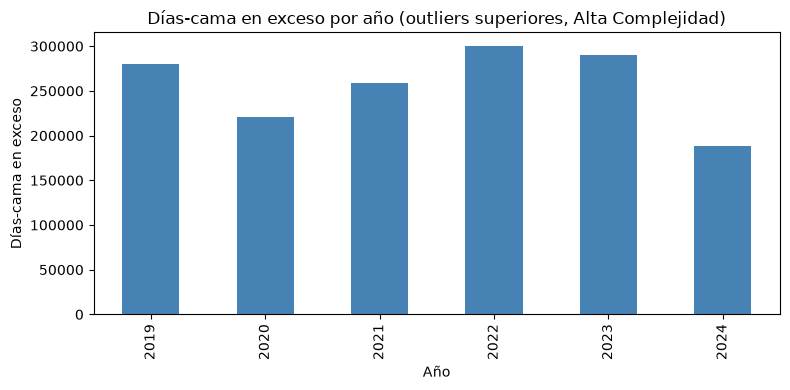

In [64]:
# Visualización de la tendencia anual de días-cama en exceso
fig, ax = plt.subplots(figsize=(8, 4))
tendencia_anual['dias_exceso'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Días-cama en exceso por año (outliers superiores, Alta Complejidad)')
ax.set_xlabel('Año')
ax.set_ylabel('Días-cama en exceso')
plt.tight_layout()
plt.show()

In [65]:
# ¿Los outliers son mayoritariamente casos terminales (estancia inevitable) o son evitables con mejor gestión de alta?
print(f"Tasa de mortalidad en outliers superiores: {outliers['FALLECIDO'].mean()*100:.1f}%")
print(f"Tasa de mortalidad general (Alta Complejidad): {grd_alta['FALLECIDO'].mean()*100:.1f}%")
print()
print("Distribución de TIPOALTA en outliers superiores:")
outliers['TIPOALTA'].value_counts(normalize=True).head(6) * 100

Tasa de mortalidad en outliers superiores: 12.9%
Tasa de mortalidad general (Alta Complejidad): 17.4%

Distribución de TIPOALTA en outliers superiores:


TIPOALTA
DOMICILIO                                       63.336951
FALLECIDO                                       12.853301
HOSPITALIZACIÓN DOMICILIARIA                    10.980041
DERIVACIÓN OTRO HOSPITAL DEL SERVICIO            5.563158
DERIVACIÓN OTRO HOSPITAL DE LA RED NACIONAL      4.090973
DERIVACIÓN A OTROS CENTROS (CÁRCEL, HOGAR DE     1.656207
Name: proportion, dtype: float64

In [66]:
n_pacientes = grd_parquet['CIP_ENCRIPTADO'].nunique()
reingresos = grd_parquet['CIP_ENCRIPTADO'].value_counts()
print(f"Registros totales: {len(grd_parquet):,}")
print(f"Pacientes únicos (CIP_ENCRIPTADO): {n_pacientes:,}")
print(f"Pacientes con más de un egreso (reingreso potencial): {(reingresos > 1).sum():,}")
print("Nota: 'SIN INFORMACIÓN' y 'DESCONOCIDO' son códigos placeholder, no pacientes reales.")

Registros totales: 367,895
Pacientes únicos (CIP_ENCRIPTADO): 325,342
Pacientes con más de un egreso (reingreso potencial): 31,064
Nota: 'SIN INFORMACIÓN' y 'DESCONOCIDO' son códigos placeholder, no pacientes reales.
